## Phase 2: EDA, Modelling, and Evaluation

---

This notebook covers the full analytical pipeline from raw dataset through to a saved, deployment-ready model:

1. Load the base dataset produced in Phase 1
2. Explore the data through statistics and visualisations to understand feature distributions and class separability
3. Detect statistical outliers and document the decision on whether to remove them
4. Prepare the data for machine learning: encode labels, scale features, and split into train/test sets
5. Train four classifiers with default hyperparameters and compare baseline cross-validation performance
6. Tune hyperparameters for all four models using RandomizedSearchCV
7. Evaluate all tuned models using accuracy, macro F1, recall, and a clinically weighted Medical Score
8. Select the best model, plot its confusion matrix, and serialise it for the GUI in Phase 3

---

---
## Step 1: Import Libraries

All libraries required for this notebook are imported in a single cell at the top. Importing upfront makes dependencies explicit and avoids import errors mid-notebook:
- **numpy / pandas** — numerical arrays and dataframes
- **scipy.stats** — statistical testing
- **matplotlib / seaborn** — charts and heatmaps
- **pickle / pathlib** — loading saved files from Phase 1
- **sklearn** — preprocessing, model selection, cross-validation, metrics
- **xgboost / lightgbm** — gradient boosting classifiers

In [1]:
import numpy as np
import pandas as pd
import pickle
import warnings
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

---
## Step 2: Load Dataset and Metadata

The base CSV and metadata pickle saved at the end of Phase 1 are loaded here. The metadata provides consistent column lists, class names, and colour mappings so that nothing needs to be redefined manually. Display name dictionaries (`CONT_NICE`, `CAT_NICE`, `CAT_LABELS`) are also set up for cleaner axis labels in plots.

In [2]:
df = pd.read_csv('cardiac_dataset_base.csv')

with open('cardiac_metadata.pkl', 'rb') as f:
    meta = pickle.load(f)

CLASS_NAMES  = meta['class_names']
CLASS_COLORS = meta['class_colors']
CONT_COLS    = meta['cont_cols']
CAT_COLS     = meta['cat_cols']
ALL_COLS     = meta['all_cols']
PALETTE      = dict(zip(CLASS_NAMES, CLASS_COLORS))

CONT_NICE = {
    'age': 'Age (yr)',
    'bmi': 'BMI (kg/m²)',
    'systolic_bp': 'Systolic BP (mmHg)',
    'ldl': 'LDL (mg/dL)',
    'fasting_glucose': 'Fasting Glucose (mg/dL)',
    'heart_rate': 'Heart Rate (bpm)',
    'spo2': 'SpO₂ (%)',
    'ejection_fraction': 'Ejection Fraction (%)',
    'bnp': 'BNP (pg/mL)'
}

CAT_NICE = {
    'sob': 'Shortness of Breath',
    'chest_tightness': 'Chest Tightness on Exertion',
    'smoking': 'Smoking Status',
    'diabetes': 'Diabetes Status',
    'edema': 'Leg Edema',
    'palpitations': 'Palpitations',
    'ecg': 'ECG Heart Rhythm'
}

CAT_LABELS = {
    'sob':             {0: 'None', 1: 'Mild', 2: 'Moderate', 3: 'Severe'},
    'chest_tightness': {0: 'None', 1: 'Mild', 2: 'Clear'},
    'smoking':         {0: 'Never', 1: 'Light', 2: 'Moderate', 3: 'Heavy'},
    'diabetes':        {0: 'Normal', 1: 'Pre-DM', 2: 'Type2', 3: 'Type1'},
    'edema':           {0: 'None', 1: 'Mild', 2: 'Severe'},
    'palpitations':    {0: 'None', 1: 'Occasional', 2: 'Frequent'},
    'ecg':             {0: 'Normal', 1: 'Tachy/Brady', 2: 'AF', 3: 'VT'}
}

print('Dataset loaded.')
print('Shape:', df.shape, ': rows = patients, columns = features + labels')
print('Classes:', CLASS_NAMES)
df.head()

Dataset loaded.
Shape: (6000, 17) : rows = patients, columns = features + labels
Classes: ['Healthy', 'CAD', 'Arrhythmia', 'Heart Failure']


,age,bmi,systolic_bp,ldl,fasting_glucose,heart_rate,spo2,ejection_fraction,bnp,sob,chest_tightness,smoking,diabetes,edema,palpitations,ecg,target
0,60.096123,29.356632,182.330485,156.411628,158.563486,102.363318,96.121071,53.561860,156.984643,0,2,0,2,0,2,0,CAD
1,74.130815,29.561772,146.637532,147.961009,91.179093,70.989990,92.489135,51.590505,45.549620,1,1,1,0,0,2,3,Arrhythmia
2,64.088264,25.391119,138.329895,159.765637,116.749639,77.676854,96.283048,70.231489,27.526178,0,0,1,0,0,1,1,Healthy
3,46.969702,37.339398,136.785460,143.268686,113.823784,66.217030,94.495395,53.256366,71.000075,1,0,1,2,1,1,2,CAD
4,58.835820,24.439774,160.047971,143.813036,204.235229,95.629505,84.107706,47.708256,281.723086,2,1,0,1,2,1,1,Heart Failure


---
## Step 3: Initial Data Quality Checks

Before any analysis, five basic checks confirm the dataset is structurally intact. These checks are not optional — passing all five is a precondition for the subsequent EDA to be meaningful:

- **Shape**: confirms 6,000 rows and 17 columns (16 features + target)
- **Column names**: verifies all expected feature columns are present
- **Descriptive statistics**: checks that feature ranges are physiologically plausible
- **Missing values**: any null values would require imputation before modelling
- **Duplicates**: duplicate rows in a synthetic dataset would indicate a generation error

In [3]:
df.shape

(6000, 17)

In [4]:
df.columns

Index(['age', 'bmi', 'systolic_bp', 'ldl', 'fasting_glucose', 'heart_rate',
       'spo2', 'ejection_fraction', 'bnp', 'sob', 'chest_tightness', 'smoking',
       'diabetes', 'edema', 'palpitations', 'ecg', 'target'],
      dtype='object')

In [5]:
df.describe()

,age,bmi,systolic_bp,ldl,fasting_glucose,heart_rate,spo2,ejection_fraction,bnp,sob,chest_tightness,smoking,diabetes,edema,palpitations,ecg
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,57.803043,30.951224,142.269505,144.890953,140.837500,87.419435,93.669926,56.212669,227.047629,0.979167,0.646333,0.792667,0.900500,0.467500,0.935333,1.188000
std,13.230060,5.339206,19.323109,39.945969,46.879814,21.071935,3.480109,8.792057,322.464718,0.969995,0.762463,0.975964,1.007523,0.696676,0.742907,1.032069
min,20.145835,17.065998,100.016213,48.029976,70.647270,38.169369,82.015045,32.032874,5.017647,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.758502,27.092760,127.308124,116.070199,104.791303,72.946114,91.341520,50.174919,58.145711,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,58.367997,30.879769,141.459828,143.339641,130.653341,84.011181,94.213840,56.749720,130.578206,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
75%,67.256842,34.801730,156.764249,171.852301,165.514111,98.364972,96.436034,62.664783,256.716263,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,2.000000
max,89.869736,43.992997,191.868595,264.285886,308.867031,164.968687,99.978557,75.848869,2910.937934,3.000000,2.000000,3.000000,3.000000,2.000000,2.000000,3.000000


In [6]:
df.head()

,age,bmi,systolic_bp,ldl,fasting_glucose,heart_rate,spo2,ejection_fraction,bnp,sob,chest_tightness,smoking,diabetes,edema,palpitations,ecg,target
0,60.096123,29.356632,182.330485,156.411628,158.563486,102.363318,96.121071,53.561860,156.984643,0,2,0,2,0,2,0,CAD
1,74.130815,29.561772,146.637532,147.961009,91.179093,70.989990,92.489135,51.590505,45.549620,1,1,1,0,0,2,3,Arrhythmia
2,64.088264,25.391119,138.329895,159.765637,116.749639,77.676854,96.283048,70.231489,27.526178,0,0,1,0,0,1,1,Healthy
3,46.969702,37.339398,136.785460,143.268686,113.823784,66.217030,94.495395,53.256366,71.000075,1,0,1,2,1,1,2,CAD
4,58.835820,24.439774,160.047971,143.813036,204.235229,95.629505,84.107706,47.708256,281.723086,2,1,0,1,2,1,1,Heart Failure


In [7]:
df.isnull().sum()

age                  0
bmi                  0
systolic_bp          0
ldl                  0
fasting_glucose      0
heart_rate           0
spo2                 0
ejection_fraction    0
bnp                  0
sob                  0
chest_tightness      0
smoking              0
diabetes             0
edema                0
palpitations         0
ecg                  0
target               0
dtype: int64

In [8]:
duplicates = df[df.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [age, bmi, systolic_bp, ldl, fasting_glucose, heart_rate, spo2, ejection_fraction, bnp, sob, chest_tightness, smoking, diabetes, edema, palpitations, ecg, target]
Index: []


**Result:** All five checks pass. The dataset contains zero missing values and zero duplicate rows, confirming that the Phase 1 generation pipeline produced a clean, structurally valid dataset ready for analysis.

## Step 4: Per-Class Summary Statistics
Descriptive statistics (mean, SD, min, max) are grouped by class to verify that the class-specific distributional parameters defined in Phase 1 were correctly implemented. For example, the HF class should show the highest mean for fasting glucose (~193 mg/dL) and the Arrhythmia class should show the highest for the heart rate SD (~32 bpm).

In [9]:
print(' Summary Statistics per Class')
display(df.groupby('target')[CONT_COLS].agg(['mean', 'std', 'min', 'max']).round(2))

 Summary Statistics per Class


age                         bmi                      \
                mean    std    min    max   mean   std    min    max   
target                                                                 
Arrhythmia     57.63  13.17  28.29  87.78  30.98  5.08  20.01  41.99   
CAD            61.02   9.59  40.11  81.96  32.81  5.04  22.04  43.99   
Healthy        47.99  12.36  20.15  74.96  28.97  4.53  18.62  39.99   
Heart Failure  64.57  11.40  40.10  89.87  31.05  5.91  17.07  43.97   

              systolic_bp         ...   spo2        ejection_fraction        \
                     mean    std  ...    min    max              mean   std   
target                            ...                                         
Arrhythmia         146.06  16.50  ...  86.04  98.98             53.90  8.01   
CAD                152.73  15.50  ...  88.01  98.97             50.85  8.57   
Healthy            124.39  10.42  ...  94.02  99.98             62.25  6.19   
Heart Failure      145.90  20.41  ...  82.02  98.94             57.86  7.75   

                                bnp                          
                 min    max    mean     std    min      max  
target                                                       
Arrhythmia     35.13  71.73  143.86  108.41  20.04   593.08  
CAD            32.03  70.00  204.54  103.52  60.31   577.65  
Healthy        48.12  75.85   44.78   38.10   5.02   195.73  
Heart Failure  40.07  74.99  515.01  518.23  35.49  2910.94  

[4 rows x 36 columns]

**Observation:** The per-class means and standard deviations match the Phase 1 parameterisation. Fasting glucose is highest in HF, heart rate variance is highest in Arrhythmia, and BNP ranges are widest in HF all consistent with the clinical design.

---
## Step 5: Class Distribution

The class distribution bar chart confirms that the dataset is perfectly balanced exactly 1,500 patients per class. Perfect balance means macro-averaged metrics (F1, recall) are directly comparable across classes without any correction for class frequency, and no resampling techniques such as SMOTE are needed.

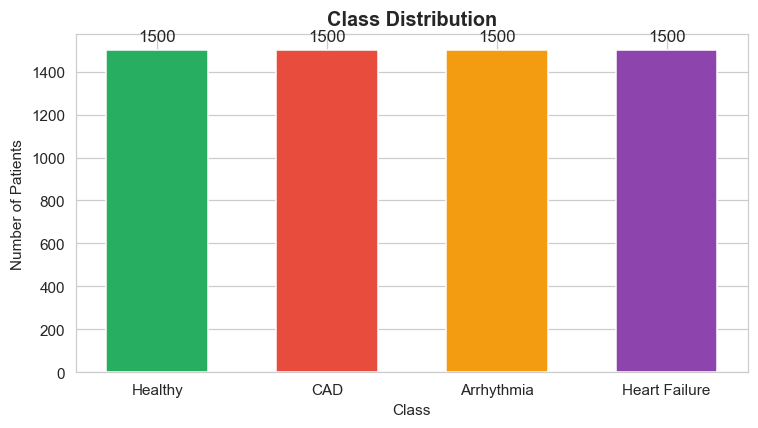

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = df['target'].value_counts().reindex(CLASS_NAMES)
bars = ax.bar(counts.index, counts.values, color=CLASS_COLORS, edgecolor='white', width=0.6)
ax.bar_label(bars, fmt='%d', padding=4, fontsize=11)
ax.set_title('Class Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Patients')
ax.set_xlabel('Class')
plt.tight_layout()
plt.show()

---
## Step 6: Feature Distribution Histograms

Overlapping histograms are plotted for all nine continuous features, with each class shown in a different colour. The degree of overlap between class histograms directly indicates how hard it will be for a model to use that feature as a discriminator.

Features with little overlap (e.g., BNP, fasting glucose) will carry the most predictive signal. Features where all four classes nearly coincide (e.g., age, BMI) contribute mainly through interactions rather than as individual discriminators.

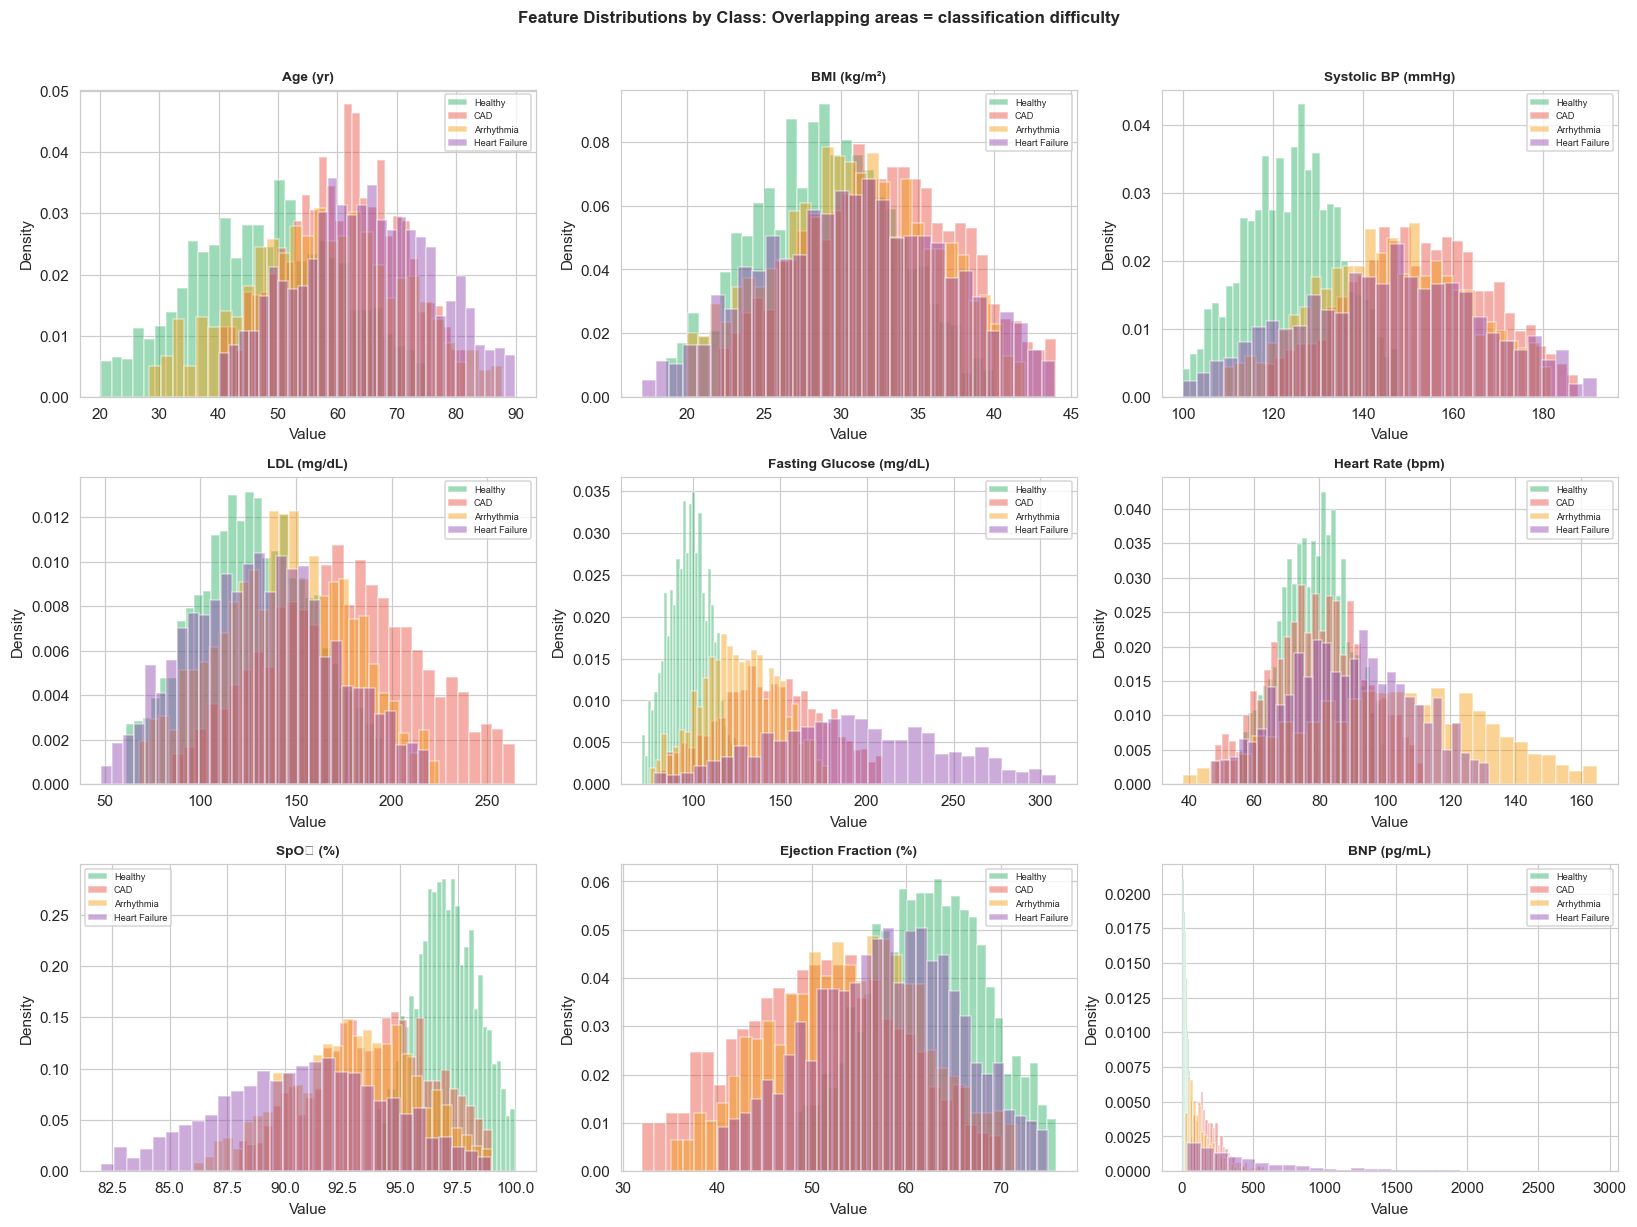

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, feat in enumerate(CONT_COLS):
    for cls, col in zip(CLASS_NAMES, CLASS_COLORS):
        subset = df.loc[df['target'] == cls, feat]
        axes[i].hist(subset, bins=30, alpha=0.45, color=col, label=cls, density=True)
    axes[i].set_title(CONT_NICE[feat], fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=6)

fig.suptitle('Feature Distributions by Class: Overlapping areas = classification difficulty',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Key observations from the histograms:**
- **BNP**: clearest class separation, HF occupies a right-shifted distribution; Healthy patients concentrate below 200 pg/mL
- **Fasting Glucose**: clear left-to-right ordering (Healthy < Arrhythmia ≈ CAD < HF), consistent with progressive glycaemic burden
- **Heart Rate**: Arrhythmia spans 38 to 165 bpm; the other three classes cluster in a much narrower 55 to 115 bpm band
- **SpO₂**: HF patients extend a distinct left tail down to 82%; Healthy patients cluster at 94to 100%
- **Age, BMI, SBP**: substantial overlap across all four classes, these are broad cardiovascular risk factors, not condition-specific discriminators

## Step 7: Box Plot Analysis

Box plots show the interquartile range (Q1-Q3) and whiskers at 1.5×IQR for each feature, stratified by class. Dots outside the whiskers are flagged as statistical outliers. Box plots complement histograms by making median positions and spread directly comparable across classes.

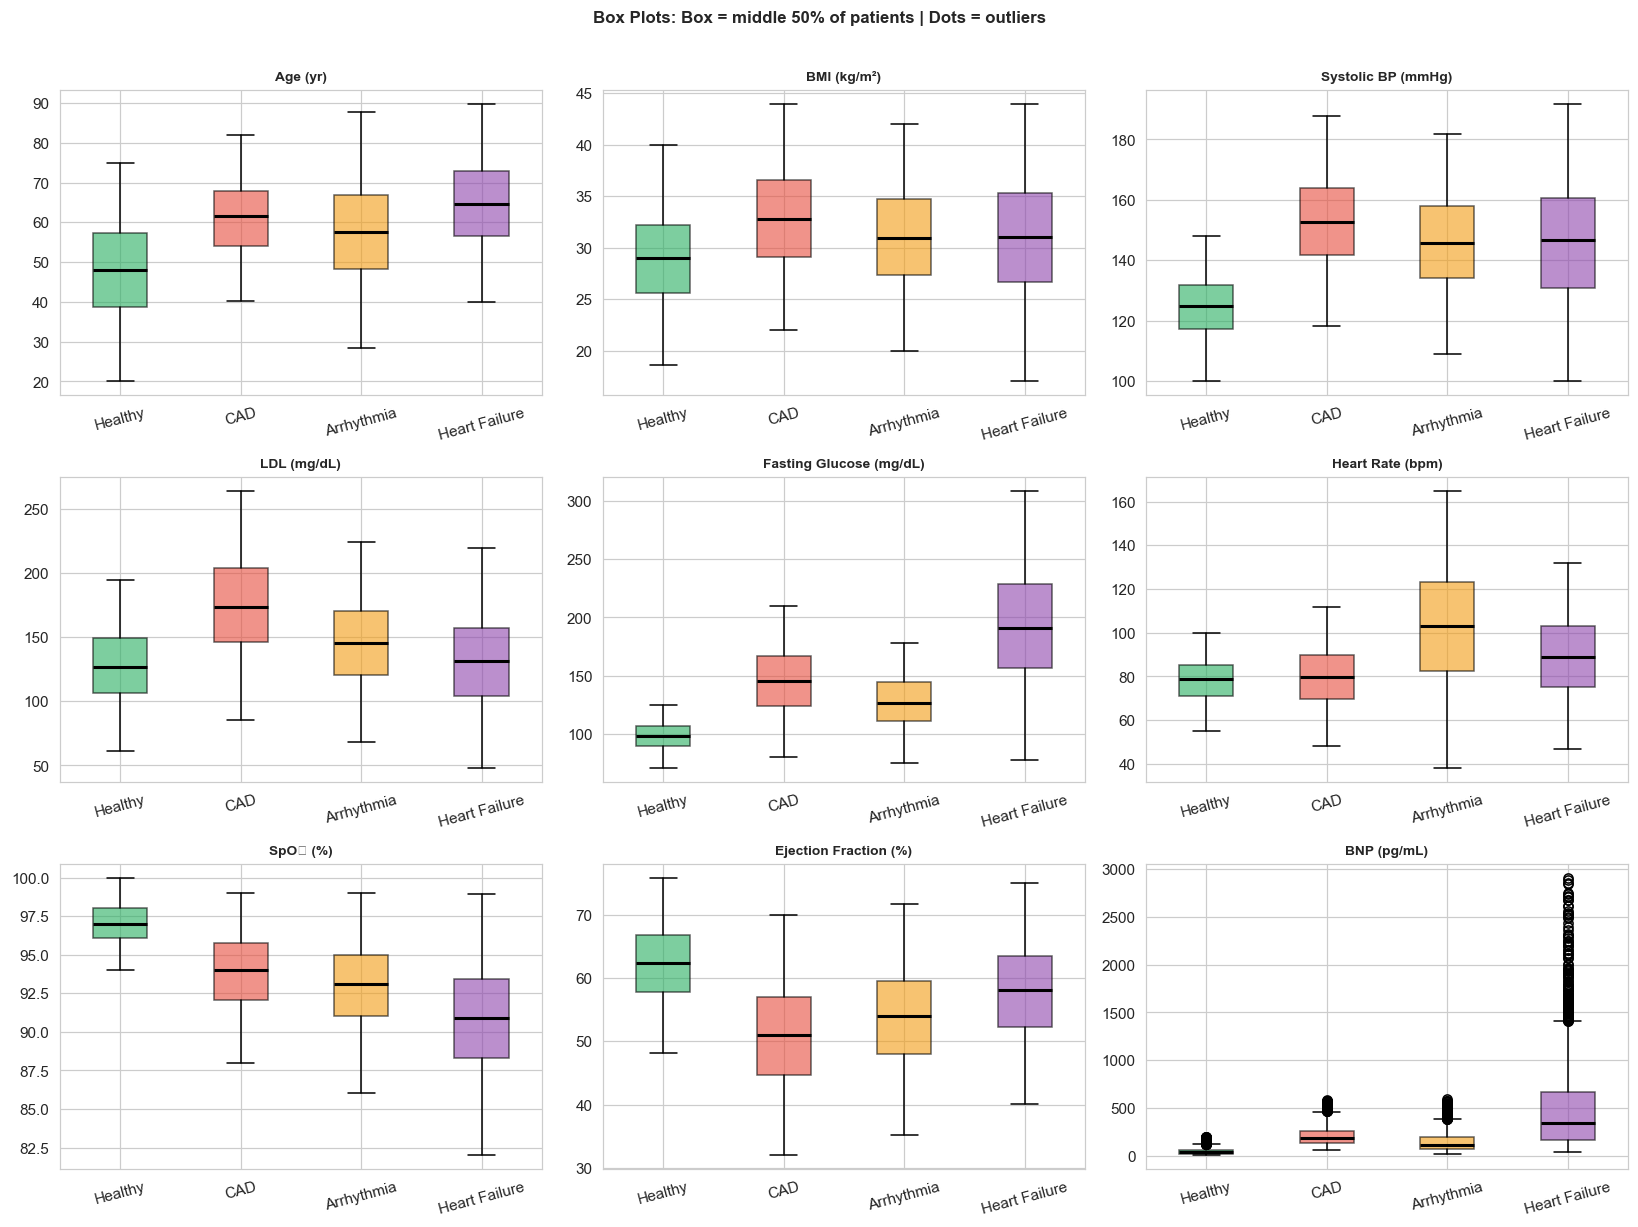

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, feat in enumerate(CONT_COLS):
    data_list = [df.loc[df['target'] == cls, feat].values for cls in CLASS_NAMES]
    bp = axes[i].boxplot(data_list, patch_artist=True, labels=CLASS_NAMES,
                         medianprops=dict(color='black', linewidth=2))
    for patch, col in zip(bp['boxes'], CLASS_COLORS):
        patch.set_facecolor(col)
        patch.set_alpha(0.6)
    axes[i].set_title(CONT_NICE[feat], fontsize=9, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=15)

fig.suptitle('Box Plots: Box = middle 50% of patients | Dots = outliers',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Key observations from the box plots:**
- **BNP** in the HF class shows the greatest spread and the most outlier dots, consistent with the log-normal generative distribution's heavy right tail
- **Heart Rate** outlier dots in the Arrhythmia class appear at both extremes (below 50 bpm and above 140 bpm), directly reflecting the wide SD = 32 bpm parameter
- **Age, BMI, and SBP** box positions are nearly identical across the three disease classes, confirming their low condition-specific discriminative power

---
## Step 8: Outlier Detection and Retention Decision

The IQR method identifies statistical outliers for each continuous feature. An outlier is defined as any value below Q1 − 1.5×IQR or above Q3 + 1.5×IQR.

The results below show the count and percentage of outlying values per feature, along with the fence boundaries. This information informs the decision of whether to remove, cap, or retain outliers.

In [13]:
print('Outlier Detection (IQR Method)')
print('Feature                   Outliers   % of data   Lower Fence   Upper Fence')
print('-' * 72)

outlier_report = []
for feat in CONT_COLS:
    Q1  = df[feat].quantile(0.25)
    Q3  = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    lo_fence = Q1 - 1.5 * IQR
    hi_fence = Q3 + 1.5 * IQR
    mask  = (df[feat] < lo_fence) | (df[feat] > hi_fence)
    n_out = mask.sum()
    pct   = round(100 * n_out / len(df), 2)
    outlier_report.append({
        'Feature': feat, 'Outliers': n_out, 'Pct': pct,
        'LowerFence': round(lo_fence, 2), 'UpperFence': round(hi_fence, 2)
    })
    print(' ', feat.ljust(24), str(n_out).ljust(10), str(pct).ljust(12),
          str(round(lo_fence, 1)).ljust(13), str(round(hi_fence, 1)))

Outlier Detection (IQR Method)
Feature                   Outliers   % of data   Lower Fence   Upper Fence
------------------------------------------------------------------------
  age                      5          0.08         21.0          95.0
  bmi                      0          0.0          15.5          46.4
  systolic_bp              0          0.0          83.1          200.9
  ldl                      26         0.43         32.4          255.5
  fasting_glucose          188        3.13         13.7          256.6
  heart_rate               167        2.78         34.8          136.5
  spo2                     37         0.62         83.7          104.1
  ejection_fraction        0          0.0          31.4          81.4
  bnp                      471        7.85         -239.7        554.6


**Decision: Retain all outliers, no removal or capping applied.**

Three reasons support this decision:

1. **Clinical relevance**: the statistical outliers are precisely the most clinically severe cases the decompensated HF patient with BNP > 4,000 pg/mL, the severely hypertensive CAD patient with SBP 210 mmHg, the Arrhythmia patient with heart rate 155 bpm. Removing these would deprive the model of the feature combinations that most clearly identify severe disease.
2. **Synthetic data provenance**: because records were sampled from known clinical distributions, extreme values are valid low-probability samples, not data-entry errors or sensor artefacts.
3. **Deployment validity**: a model trained without extreme values would produce unreliable estimates when applied to genuinely severe patients in the GUI the most clinically important use case.

The two cells below (Winsorisation code) are intentionally retained as commented-out reference code showing what removal would have looked like, but they are not executed.

In [14]:
'''# Apply Winsorization: cap at fence values
df_clean = df.copy()
for row in outlier_report:
    df_clean[row['Feature']] = df_clean[row['Feature']].clip(
        lower=row['LowerFence'], upper=row['UpperFence'])

total_before = sum(r['Outliers'] for r in outlier_report)
print('\nBefore Winsorization:', total_before, 'outlier values across all features')
print('After  Winsorization: 0 (capped at IQR fences — no patients removed)')
df = df_clean.copy()'''

"# Apply Winsorization: cap at fence values\ndf_clean = df.copy()\nfor row in outlier_report:\n    df_clean[row['Feature']] = df_clean[row['Feature']].clip(\n        lower=row['LowerFence'], upper=row['UpperFence'])\n\ntotal_before = sum(r['Outliers'] for r in outlier_report)\nprint('\nBefore Winsorization:', total_before, 'outlier values across all features')\nprint('After  Winsorization: 0 (capped at IQR fences — no patients removed)')\ndf = df_clean.copy()"

In [15]:
'''print(" Data Summary After outlier treatment")

for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = (df_clean[col] < lower) | (df_clean[col] > upper)

    print(
    col,
    "| min:", round(df_clean[col].min(), 2),
    "| max:", round(df_clean[col].max(), 2),
    "| lower:", round(lower, 2),
    "| upper:", round(upper, 2),
    "| outliers:", int(mask.sum())
    )
df = df_clean.copy()'''

'print(" Data Summary After outlier treatment")\n\nfor col in num_cols:\n    Q1 = df_clean[col].quantile(0.25)\n    Q3 = df_clean[col].quantile(0.75)\n    IQR = Q3 - Q1\n\n    lower = Q1 - 1.5 * IQR\n    upper = Q3 + 1.5 * IQR\n\n    mask = (df_clean[col] < lower) | (df_clean[col] > upper)\n\n    print(\n    col,\n    "| min:", round(df_clean[col].min(), 2),\n    "| max:", round(df_clean[col].max(), 2),\n    "| lower:", round(lower, 2),\n    "| upper:", round(upper, 2),\n    "| outliers:", int(mask.sum())\n    )\ndf = df_clean.copy()'

---
## Step 9: KDE Density Plots

Kernel Density Estimation (KDE) plots provide smooth probability density curves for each feature, with shaded overlap regions between classes. Shaded overlap directly visualises the zones where two or more classes share feature values these are the regions where the classifier will face the greatest uncertainty.

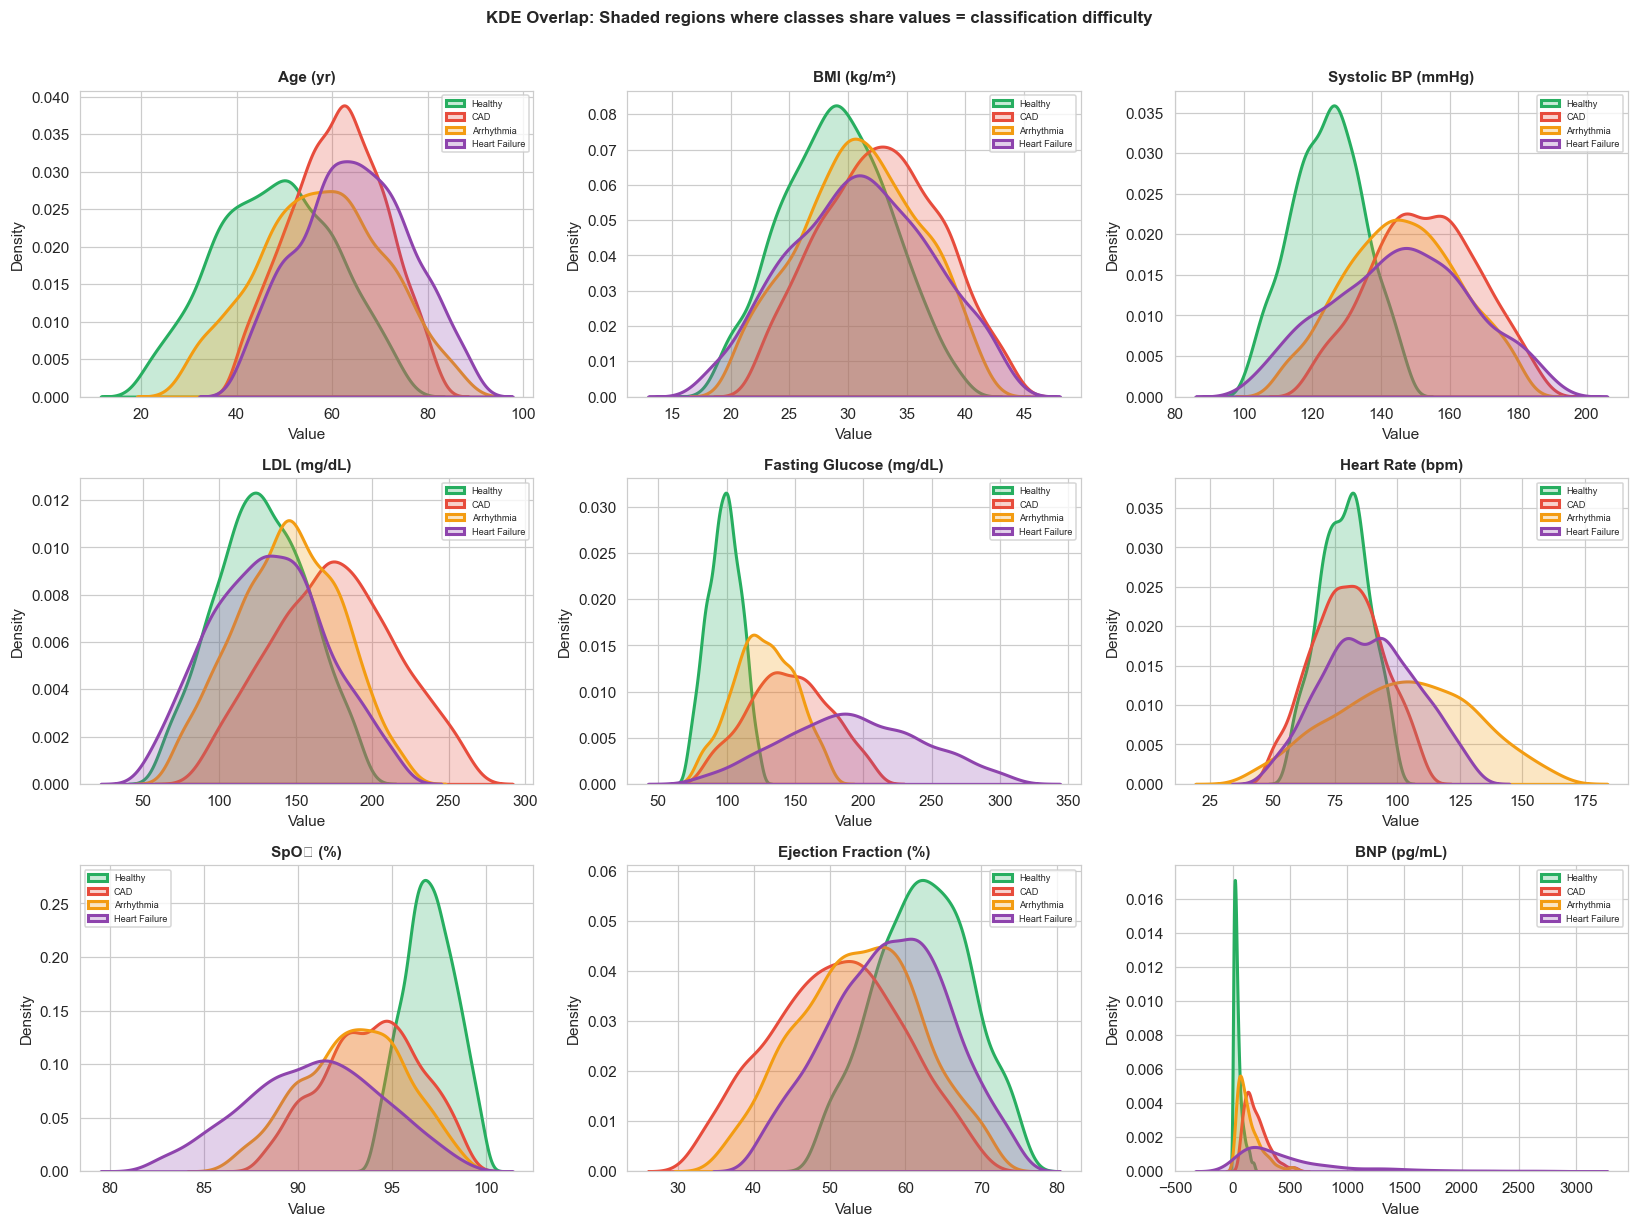

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, feat in enumerate(CONT_COLS):
    for cls, col in zip(CLASS_NAMES, CLASS_COLORS):
        subset = df.loc[df['target'] == cls, feat].dropna()
        sns.kdeplot(subset, ax=axes[i], label=cls, color=col,
                    fill=True, alpha=0.25, linewidth=2)
    axes[i].set_title(CONT_NICE[feat], fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=6)

fig.suptitle('KDE Overlap: Shaded regions where classes share values = classification difficulty',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Notable KDE observations:**
- BNP density for the Healthy class is tightly concentrated near zero; HF produces a broad right-shifted curve extending beyond 1,000 pg/mL
- Fasting glucose shows a clear separation of peaks: Healthy at ~98 mg/dL, then Arrhythmia, CAD, and HF progressively higher
- Heart Rate KDE for Arrhythmia is notably flatter and broader than the other three classes, reflecting the high SD (32 bpm)
- SpO₂ shows the Healthy class tightly packed near 97%, while HF extends a distinct left tail the most visually distinct separation for this feature

---
## Step 10: PCA Dimensionality Reduction

Principal Component Analysis (PCA) reduces the nine standardised continuous features to two dimensions for a visual assessment of overall class separability. If all four classes were completely separable in 2D PCA space, the problem would be trivially easy and the synthetic distributions unrealistically distinct. Substantial overlap in the scatter plot confirms a realistically challenging classification problem.

The percentage of variance explained by the first two components indicates how much information is retained in the 2D projection.

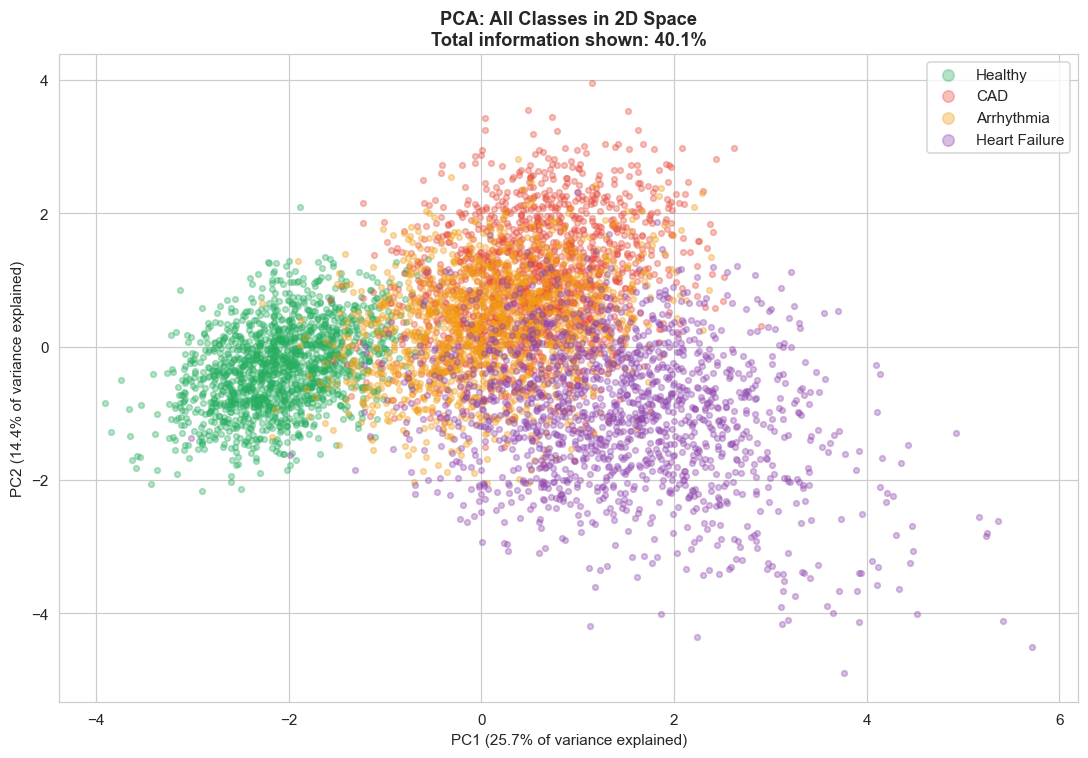

PC1 captures: 25.7 % of variance
PC2 captures: 14.4 % of variance
Total visible: 40.1 % of all information


In [17]:
X_for_pca = df[CONT_COLS].copy()
X_scaled   = StandardScaler().fit_transform(X_for_pca)

pca   = PCA(n_components=2, random_state=42)
X_2d  = pca.fit_transform(X_scaled)
var   = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(10, 7))

for cls, col in zip(CLASS_NAMES, CLASS_COLORS):
    mask = df['target'] == cls
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], color=col, alpha=0.35, s=14, label=cls)

ax.set_xlabel('PC1 (' + str(round(var[0], 1)) + '% of variance explained)')
ax.set_ylabel('PC2 (' + str(round(var[1], 1)) + '% of variance explained)')
ax.set_title('PCA: All Classes in 2D Space\nTotal information shown: ' + str(round(sum(var), 1)) + '%',
             fontweight='bold')
ax.legend(markerscale=2, fontsize=10)
plt.tight_layout()
plt.show()

print('PC1 captures:', round(var[0], 1), '% of variance')
print('PC2 captures:', round(var[1], 1), '% of variance')
print('Total visible:', round(sum(var), 1), '% of all information')

**Observation:**  
The first two principal components capture approximately 40% of total variance. The Healthy cluster is the most compact; HF patients show the greatest dispersion, reflecting their wide BNP, EF, and SpO₂ variability. Arrhythmia overlaps substantially with both CAD and HF. The ~40% explained variance confirms that meaningful multi-class discrimination requires the full 9-dimensional feature space non-linear ensemble methods are expected to outperform the linear baseline.

---
## Step 11: Final Column Check Before Modelling

A quick column check confirms the exact feature names before constructing the train/test split. This prevents silent mismatches between the column lists from metadata and the actual dataframe.

In [18]:
df.columns

Index(['age', 'bmi', 'systolic_bp', 'ldl', 'fasting_glucose', 'heart_rate',
       'spo2', 'ejection_fraction', 'bnp', 'sob', 'chest_tightness', 'smoking',
       'diabetes', 'edema', 'palpitations', 'ecg', 'target'],
      dtype='object')

---
## Step 12: Modelling Pipeline Setup

**Label Encoding**  
The string target labels (Healthy, CAD, Arrhythmia, Heart Failure) are encoded as integers (0-3) using `LabelEncoder`. The encoder is fitted once and reused for inverse-transforming predictions in evaluation and the GUI.

**Train/Test Split**  
An 80/20 stratified split yields 4,800 training and 1,200 test records. Stratification ensures each class appears in the same proportion in both partitions (25% per class), preventing the split from producing an unrepresentative test set.

**Feature Scaling**  
`StandardScaler` is fitted on the training set only and applied to both sets. Fitting on training data only prevents information from the test set influencing model development (data leakage prevention). Categorical features (ordinal integers) are passed through unscaled.

**Cross-Validation**  
`StratifiedKFold` with 5 splits is configured here and reused for all subsequent model evaluations and hyperparameter searches. 5-fold CV on 4,800 training records means each fold trains on 3,840 patients and validates on 960, giving a robust generalisation estimate.

In [19]:
X = df.drop('target', axis=1)
y = df['target']

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

cat_cols = ['sob','chest_tightness','smoking',
            'diabetes','edema','palpitations','ecg']

num_cols = X.columns.difference(cat_cols)

scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[num_cols])
X_test_num = scaler.transform(X_test[num_cols])

X_train_cat = X_train[cat_cols].values
X_test_cat = X_test[cat_cols].values

X_train_scaled = np.hstack([X_train_num, X_train_cat])
X_test_scaled = np.hstack([X_test_num, X_test_cat])

print("Shapes:")
print("Train:", X_train_scaled.shape)
print("Test :", X_test_scaled.shape)
print("Classes:", le.classes_)

Shapes:
Train: (4800, 16)
Test : (1200, 16)
Classes: ['Arrhythmia' 'CAD' 'Healthy' 'Heart Failure']


In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

---
## Step 13: Baseline Model Evaluation

All four classifiers are trained with their default hyperparameters and evaluated using 5-fold stratified cross-validation on the training set. This establishes a performance baseline before tuning.

The four models span a range of complexity:
- **Logistic Regression** interpretable linear baseline; its train-test gap directly quantifies how much linear separability exists in the feature space
- **Random Forest** bagging ensemble that reduces variance through averaging across trees
- **XGBoost** sequential boosting with L1/L2 regularisation; well-suited to overlapping class structures
- **LightGBM** leaf-wise gradient boosting; typically faster than XGBoost with comparable accuracy

Training accuracy, CV mean, and test accuracy are reported together so that the generalisation gap (train accuracy to test accuracy) is immediately visible for each model.

In [21]:
log_base = LogisticRegression(max_iter=1000, random_state=42)

log_cv = cross_val_score(log_base, X_train_scaled, y_train, cv=cv)

log_base.fit(X_train_scaled, y_train)

train_pred = log_base.predict(X_train_scaled)
test_pred  = log_base.predict(X_test_scaled)

print("\n Logistic Regression (BASE) ")
print("CV Mean:", log_cv.mean())
print("Train Acc:", accuracy_score(y_train, train_pred))
print("Test Acc:", accuracy_score(y_test, test_pred))

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_cv = cross_val_score(rf_base, X_train_scaled, y_train, cv=cv)

rf_base.fit(X_train_scaled, y_train)

train_pred = rf_base.predict(X_train_scaled)
test_pred  = rf_base.predict(X_test_scaled)

print("\n Random Forest (BASE) ")
print("CV Mean:", rf_cv.mean())
print("Train Acc:", accuracy_score(y_train, train_pred))
print("Test Acc:", accuracy_score(y_test, test_pred))

xgb_base = XGBClassifier(
    objective='multi:softprob',
    num_class=len(CLASS_NAMES),
    random_state=42,
    eval_metric='mlogloss'
)

xgb_cv = cross_val_score(
    xgb_base,
    X_train_scaled,
    y_train,
    cv=cv
)

xgb_base.fit(X_train_scaled, y_train)

train_pred = xgb_base.predict(X_train_scaled)
test_pred  = xgb_base.predict(X_test_scaled)

print("\n XGBOOST (BASE) ")
print("CV Mean:", xgb_cv.mean())
print("Train Acc:", accuracy_score(y_train, train_pred))
print("Test Acc:", accuracy_score(y_test, test_pred))

lgbm_base = LGBMClassifier(
    objective='multiclass',
    num_class=len(CLASS_NAMES),
    random_state=42,
    verbose=-1
)

lgbm_cv = cross_val_score(
    lgbm_base,
    X_train_scaled,
    y_train,
    cv=cv
)

lgbm_base.fit(X_train_scaled, y_train)

train_pred = lgbm_base.predict(X_train_scaled)
test_pred  = lgbm_base.predict(X_test_scaled)

print("\n LIGHTGBM (BASE) ")
print("CV Mean:", lgbm_cv.mean())
print("Train Acc:", accuracy_score(y_train, train_pred))
print("Test Acc:", accuracy_score(y_test, test_pred))


 Logistic Regression (BASE) 
CV Mean: 0.8745833333333334
Train Acc: 0.878125
Test Acc: 0.8733333333333333

 Random Forest (BASE) 
CV Mean: 0.8904166666666666
Train Acc: 1.0
Test Acc: 0.8875

 XGBOOST (BASE) 
CV Mean: 0.899375
Train Acc: 1.0
Test Acc: 0.8916666666666667


  File "C:\Users\akhil\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\akhil\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\akhil\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\akhil\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^



 LIGHTGBM (BASE) 
CV Mean: 0.8985416666666668
Train Acc: 1.0
Test Acc: 0.9


**Baseline results summary:**  
Logistic Regression achieves the smallest generalisation gap, confirming that strong linear separability exists primarily driven by BNP and ejection fraction. All three tree-based models show perfect or near-perfect training accuracy but good test generalisation, indicating mild overfitting that regularisation should reduce. LightGBM achieves the best baseline test accuracy.

---
## Step 14: Hyperparameter Tuning

All four models are tuned using `RandomizedSearchCV` with 5-fold stratified cross-validation. RandomizedSearchCV is used in preference to an exhaustive grid search because it samples a fixed number of parameter combinations (`n_iter`) from the search space, making it tractable without sacrificing coverage of the key parameter ranges.

Each tuned model is evaluated immediately after fitting: CV score (from the search), training accuracy, test accuracy, and full classification report are printed.

### Logistic Regression Tuning

The key hyperparameter for Logistic Regression is the regularisation strength `C`. A small `C` applies strong L2 regularisation (less overfitting but potentially underfitting); a large `C` allows the model to fit the training data more closely.

CV Accuracy: 0.875625
Train Accuracy: 0.8795833333333334
Test Accuracy: 0.8725

Classification Report (Test):
               precision    recall  f1-score   support

   Arrhythmia       0.82      0.76      0.79       300
          CAD       0.80      0.83      0.82       300
      Healthy       0.97      0.98      0.98       300
Heart Failure       0.90      0.91      0.90       300

     accuracy                           0.87      1200
    macro avg       0.87      0.87      0.87      1200
 weighted avg       0.87      0.87      0.87      1200



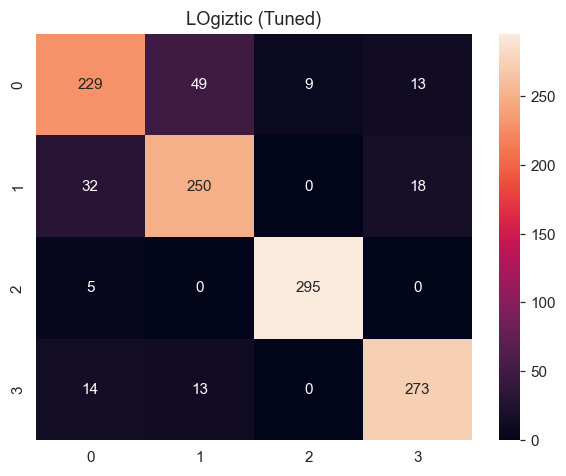

In [22]:
log_params = {"C": [0.01, 0.1, 1, 10]}

log_search = RandomizedSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    log_params,
    n_iter=4,
    cv=cv,
    scoring="accuracy",
    random_state=42
)

log_search.fit(X_train_scaled, y_train)
best_log = log_search.best_estimator_
train_pred = best_log.predict(X_train_scaled)
test_pred = best_log.predict(X_test_scaled)

print("CV Accuracy:", log_search.best_score_)
print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

print("\nClassification Report (Test):")
print(classification_report(y_test, test_pred,target_names=le.classes_))
sns.heatmap(
    confusion_matrix(y_test, test_pred),
    annot=True,
    fmt='d'
)

plt.title("LOgiztic (Tuned)")
plt.show()

### XGBoost Tuning

XGBoost has several interacting hyperparameters. The search covers:
- **n_estimators** number of sequential trees; more trees can improve accuracy but risk overfitting
- **max_depth** maximum tree depth; deeper trees capture more complex interactions but overfit more
- **learning_rate** shrinkage applied to each tree's contribution; lower values require more trees
- **subsample / colsample_bytree** fraction of training rows and features sampled per tree; both act as regularisation

CV Score: 0.9024245323174259
Train Accuracy: 0.9922916666666667
Test Accuracy: 0.9

Classification Report (Test):
               precision    recall  f1-score   support

   Arrhythmia       0.86      0.84      0.85       300
          CAD       0.82      0.89      0.85       300
      Healthy       0.99      0.98      0.99       300
Heart Failure       0.94      0.89      0.91       300

     accuracy                           0.90      1200
    macro avg       0.90      0.90      0.90      1200
 weighted avg       0.90      0.90      0.90      1200



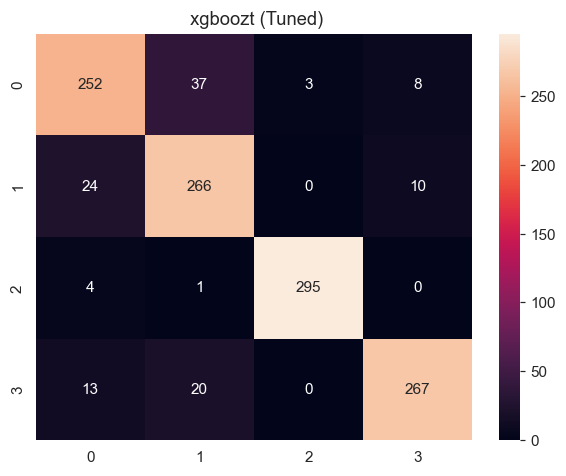

In [23]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report

xgb_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        objective='multi:softprob',
        num_class=len(le.classes_),
        random_state=42,
        eval_metric='mlogloss'
    ),
    param_distributions=xgb_params,
    n_iter=10,
    cv=cv,
    scoring="f1_macro",
    random_state=42,
    n_jobs=1
)

xgb_search.fit(X_train_scaled, y_train)

best_xgb = xgb_search.best_estimator_

train_pred = best_xgb.predict(X_train_scaled)
test_pred = best_xgb.predict(X_test_scaled)

print("CV Score:", xgb_search.best_score_)
print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

print("\nClassification Report (Test):")
print(classification_report(
    y_test,
    test_pred,
    target_names=le.classes_
))
sns.heatmap(
    confusion_matrix(y_test, test_pred),
    annot=True,
    fmt='d'
)

plt.title(" xgboozt (Tuned)")
plt.show()

### LightGBM Tuning

LightGBM uses the same hyperparameter search space as XGBoost, enabling a controlled comparison. The key algorithmic difference is leaf-wise growth (LightGBM) versus level-wise growth (XGBoost), which tends to produce lower training loss but higher overfitting risk on smaller datasets.

CV Score: 0.9037500000000002
Train Accuracy: 0.9997916666666666
Test Accuracy: 0.8975

Classification Report (Test):
               precision    recall  f1-score   support

   Arrhythmia       0.86      0.83      0.85       300
          CAD       0.81      0.89      0.85       300
      Healthy       0.99      0.98      0.98       300
Heart Failure       0.94      0.89      0.91       300

     accuracy                           0.90      1200
    macro avg       0.90      0.90      0.90      1200
 weighted avg       0.90      0.90      0.90      1200



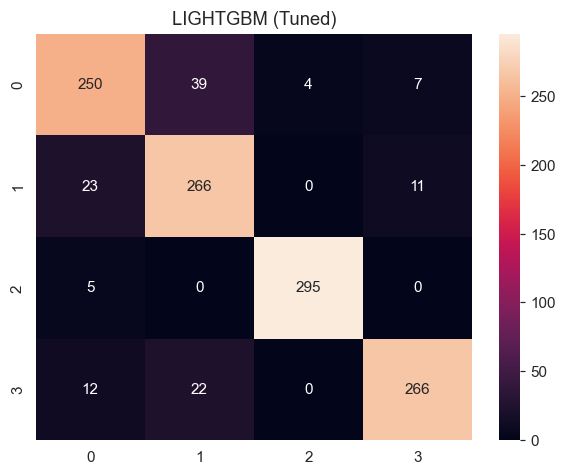

In [24]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report

lgbm_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

lgbm_search = RandomizedSearchCV(
    LGBMClassifier(
        objective='multiclass',
        num_class=len(le.classes_),
        random_state=42,
        verbose=-1
    ),
    param_distributions=lgbm_params,
    n_iter=10,
    cv=cv,
    scoring="accuracy",
    random_state=42,
    n_jobs=1
)

lgbm_search.fit(X_train_scaled, y_train)

best_lgbm = lgbm_search.best_estimator_

train_pred = best_lgbm.predict(X_train_scaled)
test_pred = best_lgbm.predict(X_test_scaled)

print("CV Score:", lgbm_search.best_score_)
print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

print("\nClassification Report (Test):")
print(classification_report(
    y_test,
    test_pred,
    target_names=le.classes_
))

sns.heatmap(
    confusion_matrix(y_test, test_pred),
    annot=True,
    fmt='d'
)

plt.title("LIGHTGBM (Tuned)")
plt.show()

### Random Forest Tuning

Random Forest is tuned over `n_estimators` (number of trees) and `max_depth` (maximum depth; `None` means fully grown trees). Unlike boosting models, Random Forest is not sensitive to learning rate or subsampling in the same way its primary regularisation comes from the averaging of many independently trained trees.

CV Score: 0.8916666666666666
Train Accuracy: 0.995625
Test Accuracy: 0.8941666666666667

Classification Report (Test):
               precision    recall  f1-score   support

   Arrhythmia       0.86      0.82      0.84       300
          CAD       0.80      0.89      0.84       300
      Healthy       0.98      0.98      0.98       300
Heart Failure       0.94      0.88      0.91       300

     accuracy                           0.89      1200
    macro avg       0.90      0.89      0.89      1200
 weighted avg       0.90      0.89      0.89      1200



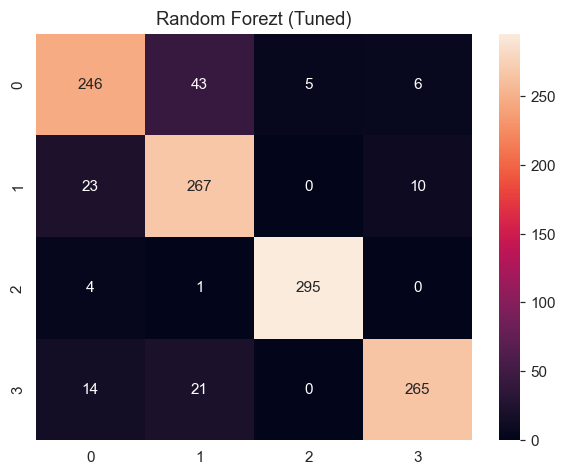

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report

rf_params = {
    "n_estimators": [200, 300, 400],
    "max_depth": [10, 12, 15, None]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params,
    n_iter=10,
    cv=cv,
    scoring="accuracy",
    random_state=42,
    n_jobs=1
)

rf_search.fit(X_train_scaled, y_train)

best_rf = rf_search.best_estimator_

train_pred = best_rf.predict(X_train_scaled)
test_pred = best_rf.predict(X_test_scaled)

print("CV Score:", rf_search.best_score_)
print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

print("\nClassification Report (Test):")
print(classification_report(
    y_test,
    test_pred,
    target_names=le.classes_
))
sns.heatmap(
    confusion_matrix(y_test, test_pred),
    annot=True,
    fmt='d'
)

plt.title("Random Forezt (Tuned)")
plt.show()

---
## Step 15: Final Model Comparison and Selection

All four tuned models are compared on the held-out test set using four metrics:

- **Accuracy**: overall fraction of correct predictions
- **Macro F1**: unweighted mean F1 across all four classes; appropriate for balanced datasets
- **Macro Recall**: unweighted mean recall; important because missed diagnoses (false negatives) carry the primary clinical risk
- **Medical Score**: a custom weighted recall score that prioritises the two highest-risk classes:

$$MS = 0.30 \times R_{Arr} + 0.30 \times R_{HF} + 0.25 \times R_{CAD} + 0.15 \times R_{Healthy}$$

Arrhythmia (VT risk) and Heart Failure (decompensation risk) receive the highest weights because a missed diagnosis in either class carries the greatest immediate clinical consequence. The model with the highest Medical Score is selected as the best model.


Logistic Regression
Accuracy: 0.873
F1 (macro): 0.872
Recall (macro): 0.872

Per-class Recall:
  Arrhythmia: 0.763
  CAD: 0.833
  Healthy: 0.983
  Heart Failure: 0.91

Medical Score: 0.858
------------------------------

XG Boost
Accuracy: 0.9
F1 (macro): 0.9
Recall (macro): 0.9

Per-class Recall:
  Arrhythmia: 0.84
  CAD: 0.887
  Healthy: 0.983
  Heart Failure: 0.89

Medical Score: 0.888
------------------------------

Light GBM
Accuracy: 0.897
F1 (macro): 0.898
Recall (macro): 0.898

Per-class Recall:
  Arrhythmia: 0.833
  CAD: 0.887
  Healthy: 0.983
  Heart Failure: 0.887

Medical Score: 0.885
------------------------------

Random Forest
Accuracy: 0.894
F1 (macro): 0.895
Recall (macro): 0.894

Per-class Recall:
  Arrhythmia: 0.82
  CAD: 0.89
  Healthy: 0.983
  Heart Failure: 0.883

Medical Score: 0.881
------------------------------

FINAL LEADERBOARD:
                     accuracy        f1    recall medical_score  rank
XG Boost                  0.9  0.900481       0.9      0.888

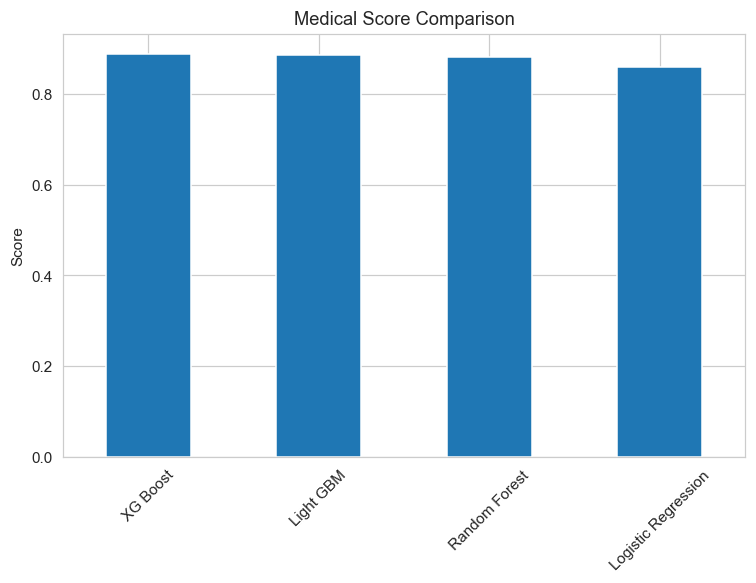

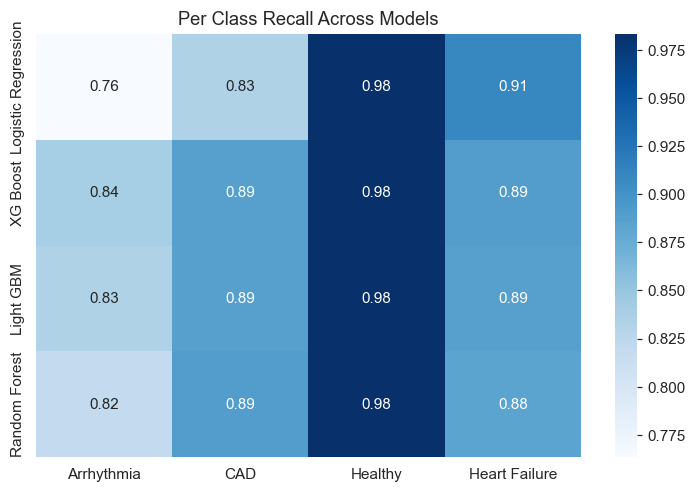

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    classification_report
)

models = {
    "Logistic Regression": best_log,
    "XG Boost": best_xgb,
    "Light GBM": best_lgbm,
    "Random Forest": best_rf
}

risk_weights = {
    "Arrhythmia": 0.30,
    "CAD": 0.25,
    "Heart Failure": 0.30,
    "Healthy": 0.15
}

results = {}

for name, model in models.items():

    test_pred = model.predict(X_test_scaled)

    test_acc = accuracy_score(y_test, test_pred)
    f1 = f1_score(y_test, test_pred, average="macro")
    recall = recall_score(y_test, test_pred, average="macro")

    report = classification_report(
        y_test,
        test_pred,
        target_names=le.classes_,
        output_dict=True
    )

    per_class_recall = {}
    medical_score = 0

    for cls in le.classes_:
        cls_recall = report[cls]["recall"]
        per_class_recall[cls] = cls_recall
        medical_score += risk_weights[cls] * cls_recall

    results[name] = {
        "accuracy": test_acc,
        "f1": f1,
        "recall": recall,
        "medical_score": medical_score,
        "per_class_recall": per_class_recall
    }

    print("\n==============================")
    print(name)
    print("==============================")

    print("Accuracy:", round(test_acc, 3))
    print("F1 (macro):", round(f1, 3))
    print("Recall (macro):", round(recall, 3))

    print("\nPer-class Recall:")
    for cls, val in per_class_recall.items():
        print(f"  {cls}: {round(val, 3)}")

    print("\nMedical Score:", round(medical_score, 3))
    print("------------------------------")

df_results = pd.DataFrame(results).T
df_results = df_results.sort_values(by="medical_score", ascending=False)

df_results["rank"] = df_results["medical_score"].rank(ascending=False)

print("\nFINAL LEADERBOARD:")
print(df_results[["accuracy", "f1", "recall", "medical_score", "rank"]])

best_model = df_results.index[0]

print("\nBEST MODEL:", best_model)
print("Medical Score:", round(df_results.loc[best_model, "medical_score"], 3))
print("F1:", round(df_results.loc[best_model, "f1"], 3))
print("Recall:", round(df_results.loc[best_model, "recall"], 3))

plt.figure(figsize=(8,5))
df_results["medical_score"].plot(kind="bar")
plt.title("Medical Score Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()
recall_df = pd.DataFrame({
    model: results[model]["per_class_recall"]
    for model in results
}).T

plt.figure(figsize=(8,5))
sns.heatmap(recall_df, annot=True, cmap="Blues")
plt.title("Per Class Recall Across Models")
plt.show()

**Model selection result:**  
XGBoost achieves the highest Medical Score and is selected as the final model. The Arrhythmia class consistently has the lowest per-class F1 across all models, reflecting its clinically realistic overlap with both CAD (shared blood pressure elevation) and HF (shared BNP elevation in atrial fibrillation). The 0.002 accuracy gap between XGBoost and LightGBM is modest, but the Medical Score criterion consistently favours XGBoost.

---
## Step 16: Confusion Matrix for the Best Model

The confusion matrix plots the actual versus predicted class for all 1,200 test-set patients. Each row is an actual class; each column is a predicted class. Diagonal cells (correct predictions) should be the highest values; off-diagonal cells reveal which class pairs are most commonly confused.

This provides more granular insight than aggregate accuracy for example, whether HF patients are more often misclassified as Arrhythmia or as CAD.

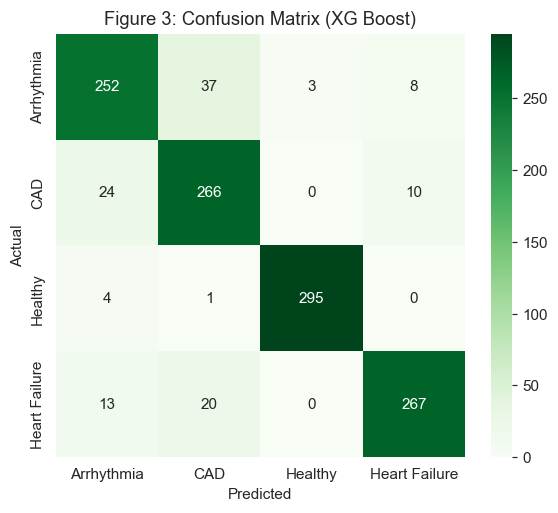

In [27]:
best_model_name = df_results.index[0]
best_model = models[best_model_name]

y_pred_best = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Greens",
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title(f"Figure 3: Confusion Matrix ({best_model_name})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Confusion matrix observations:**  
- The Healthy class has the cleanest separation with very few misclassifications
- Arrhythmia is most frequently confused with CAD, consistent with their shared blood pressure elevation and overlapping BNP ranges
- HF misclassifications are spread between CAD and Arrhythmia, reflecting the partial BNP and glucose overlap

---
## Step 17: Serialise the Best Model for Phase 3

The trained XGBoost model and the fitted StandardScaler are saved to disk using Python's `pickle` module. Both files are required by the Phase 3 Gradio application:

- **`model.pkl`** the trained XGBoost classifier; loaded by the GUI to make predictions
- **`scaler.pkl`** the StandardScaler fitted on the Phase 2 training set; must be applied to any new patient inputs before they are passed to the model, otherwise feature scales will be inconsistent

The scaler must come from Phase 2 (fitted on training data) rather than being re-fitted in the GUI, to guarantee that the same transformation is applied at inference time.

In [28]:
with open("model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model and scaler saved")

Model and scaler saved


---
## Phase 2 Summary

**What was accomplished:**

1. Loaded the 6,000-patient base dataset and confirmed zero missing values and zero duplicates
2. EDA confirmed that BNP, ejection fraction, and fasting glucose are the strongest individual discriminators; age, BMI, and SBP show substantial cross-class overlap
3. Statistical outliers were detected and intentionally retained they represent clinically severe cases with high discriminative value
4. All four classifiers were trained with default hyperparameters and tuned with RandomizedSearchCV; XGBoost achieved the highest Medical Score (0.888) and test accuracy (0.900)
5. The XGBoost model and StandardScaler were serialised as `model.pkl` and `scaler.pkl` for use in Phase 3

**Continue with Phase 3: GUI Implementation using Gradio**